In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [116]:
import os
os.chdir(r"E:\5th Semester\MLProject 5th SEM")

# Part A — Load and Understand the Data

In [88]:
# Load the dataset and show the first 10 rows.
superstore_df = pd.read_csv("Sample-Superstore.csv",  encoding='latin1')
superstore_df.columns = superstore_df.columns.str.strip().str.replace(' ', '_').str.replace('-', '_')
superstore_df.head(10)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [89]:
# Total number of rows and columns
print(superstore_df.shape)

(9994, 21)


In [90]:
# Data types of each column
print(superstore_df.dtypes)

Row_ID             int64
Order_ID          object
Order_Date        object
Ship_Date         object
Ship_Mode         object
Customer_ID       object
Customer_Name     object
Segment           object
Country           object
City              object
State             object
Postal_Code        int64
Region            object
Product_ID        object
Category          object
Sub_Category      object
Product_Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [113]:
# Number of missing values per column
print(superstore_df.isnull().sum()[superstore_df.isnull().sum() > 0])
print("---")
superstore_df.isnull().sum()

Series([], dtype: int64)
---


Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Order_Year       0
dtype: int64

In [92]:
# Check if there are any duplicate records and remove them.
#print(superstore_df.duplicated().sum())

#duplicate function tells about duplicated rows and sum tells about no of duplicate rows
initial_rows = superstore_df.shape[0]
superstore_df.drop_duplicates(inplace=True)
rows_after_removal = superstore_df.shape[0]

print(f"\nNumber of Duplicate Records Found and Removed: {initial_rows - rows_after_removal}")
print(f"Total Rows After Removing Duplicates: {rows_after_removal}")



Number of Duplicate Records Found and Removed: 0
Total Rows After Removing Duplicates: 9994


# Part B — Basic Data Cleaning and Summary

In [93]:
# Replace any missing values with appropriate substitutes (e.g., mean or “Unknown”).
superstore_df['Postal_Code'].fillna('Unknown', inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_14400\613152448.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  superstore_df['Postal_Code'].fillna('Unknown', inplace=True)


In [114]:
# Find: Average, minimum, and maximum of Sales, Profit, and Discount.
summary_stats = superstore_df[['Sales', 'Profit', 'Discount']].agg(['mean', 'min', 'max'])
summary_stats

,Sales,Profit,Discount
mean,229.858001,28.656896,0.156203
min,0.444000,-6599.978000,0.000000
max,22638.480000,8399.976000,0.800000


In [115]:
# Identify:The region with the highest total sales. The region with the lowest total sales
region_sales = superstore_df.groupby('Region')['Sales'].sum()
region_sales

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

In [96]:
highest_sales_region = region_sales.idxmax()
print(f"\nRegion with the Highest Total Sales: {highest_sales_region} (Sales: ${region_sales.max():,.2f})")


Region with the Highest Total Sales: West (Sales: $725,457.82)


In [97]:
lowest_sales_region = region_sales.idxmin()
print(f"Region with the Lowest Total Sales: {lowest_sales_region} (Sales: ${region_sales.min():,.2f})")

Region with the Lowest Total Sales: South (Sales: $391,721.91)


# Part C — Grouping and Simple Analysis

In [98]:
# Show the total sales and total profit by category.
print("\n--- Total Sales and Profit by Category ---")
category_summary = superstore_df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)
category_summary


--- Total Sales and Profit by Category ---


,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


In [99]:
# Show the average discount and average profit by sub-category.
print("\n--- Average Discount and Average Profit by Sub-Category ---")
sub_category_summary = superstore_df.groupby('Sub_Category')[['Discount', 'Profit']].mean().sort_values(by='Profit', ascending=False)
sub_category_summary


--- Average Discount and Average Profit by Sub-Category ---


,Discount,Profit
Sub_Category,,
Copiers,0.161765,817.909190
Accessories,0.078452,54.111788
Phones,0.154556,50.073938
Chairs,0.170178,43.095894
Appliances,0.166524,38.922758
Machines,0.306087,29.432669
Envelopes,0.080315,27.418019
Storage,0.074704,25.152277
Paper,0.074891,24.856620


In [100]:
# Find the top 5 cities with the highest total sales.
print("\n--- Top 5 Cities by Total Sales ---")
city_sales = superstore_df.groupby('City')['Sales'].sum().sort_values(ascending=False)
city_sales.head(5) 


--- Top 5 Cities by Total Sales ---


City
New York City    256368.161
Los Angeles      175851.341
Seattle          119540.742
San Francisco    112669.092
Philadelphia     109077.013
Name: Sales, dtype: float64

In [101]:
# Group the data by region and segment to see which combinations perform best in terms of profit.
print("\n--- Profit by Region and Segment Combination ---")

region_segment_profit = superstore_df.groupby(['Region', 'Segment'])['Profit'].sum().sort_values(ascending=False)
region_segment_profit.head(10)


--- Profit by Region and Segment Combination ---


Region   Segment    
West     Consumer       57450.6040
East     Consumer       41190.9843
West     Corporate      34437.4299
South    Consumer       26913.5728
East     Home Office    26709.2168
         Corporate      23622.5789
Central  Corporate      18703.9020
West     Home Office    16530.4150
South    Corporate      15215.2232
Central  Home Office    12438.4124
Name: Profit, dtype: float64

# Part D — Visualizations (Matplotlib)

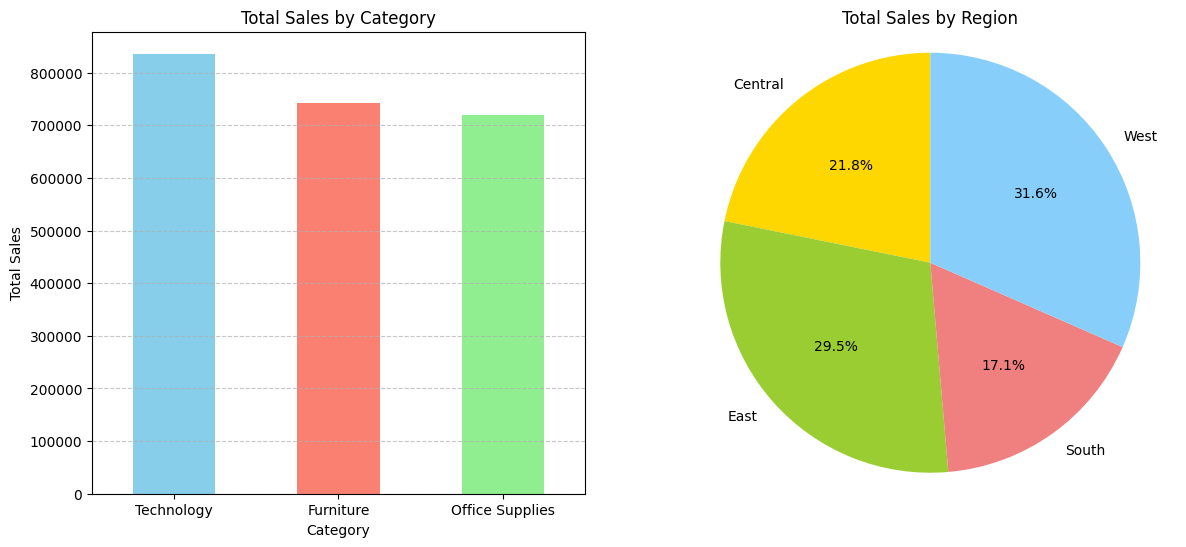

In [102]:
category_sales = superstore_df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
region_sales = superstore_df.groupby('Region')['Sales'].sum()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1 (Task 12: Bar Chart - Total Sales by Category)
category_sales.plot(kind='bar', ax=ax[0], color=['skyblue', 'salmon', 'lightgreen'])
ax[0].set(title='Total Sales by Category', xlabel='Category', ylabel='Total Sales')
ax[0].tick_params(axis='x', rotation=0)
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2 (Task 13: Pie Chart - Share of Total Sales for Each Region)
ax[1].pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=90, colors=['gold', 'yellowgreen', 'lightcoral', 'lightskyblue'])
ax[1].set(title='Total Sales by Region', ylabel=' ')
ax[1].axis('equal')

plt.show() 

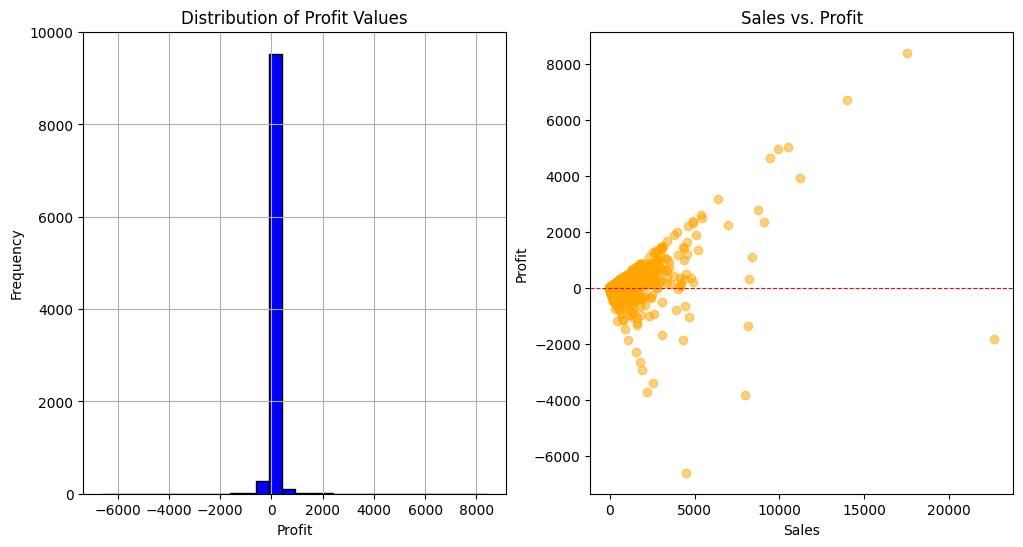

In [103]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1 (Task 14: Histogram - Distribution of Profit)
superstore_df['Profit'].hist(ax=ax[0], bins=30, color='blue', edgecolor='black')
ax[0].set(title='Distribution of Profit Values', xlabel='Profit', ylabel='Frequency')

# Subplot 2 (Task 15: Scatter Plot - Sales vs. Profit)
ax[1].scatter(superstore_df['Sales'], superstore_df['Profit'], alpha=0.5, color='orange')
ax[1].set(title='Sales vs. Profit', xlabel='Sales', ylabel='Profit')
ax[1].axhline(0, color='red', linestyle='--', linewidth=0.8) 

plt.show()

<Figure size 800x600 with 0 Axes>

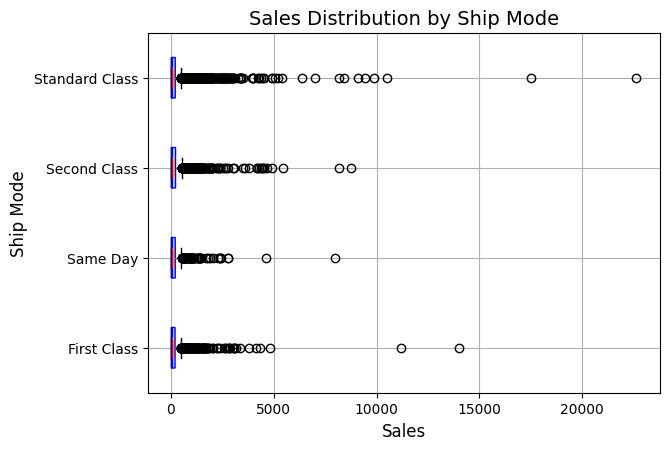

In [104]:
plt.figure(figsize=(8, 6))

# Task 16: Boxplot → show Sales for each Ship Mode.
superstore_df.boxplot(column='Sales', by='Ship_Mode', grid=True, patch_artist=True, vert=False, notch=True,
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))
plt.title('Sales Distribution by Ship Mode', fontsize=14)
plt.suptitle('') 
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Ship Mode', fontsize=12)
plt.show()

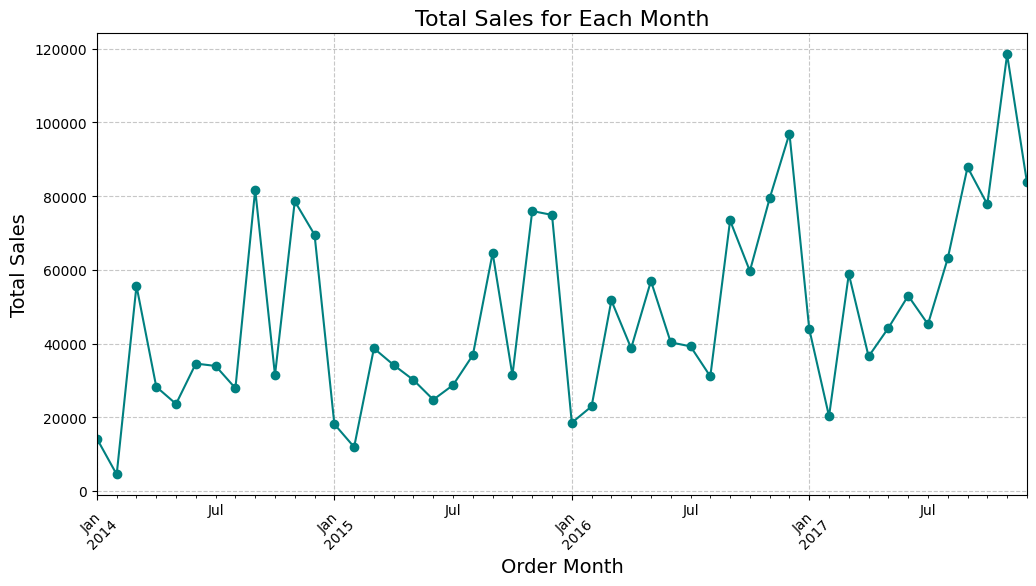

In [105]:
superstore_df['Order_Date'] = pd.to_datetime(superstore_df['Order_Date'], errors='coerce')
monthly_sales = superstore_df.set_index('Order_Date').resample('ME')['Sales'].sum().sort_index()

# Task 17: Line chart showing total sales for each month.
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', linestyle='-', color='teal')
plt.title('Total Sales for Each Month', fontsize=16)
plt.xlabel('Order Month', fontsize=14)
plt.ylabel('Total Sales', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

Part E — Deeper Analysis

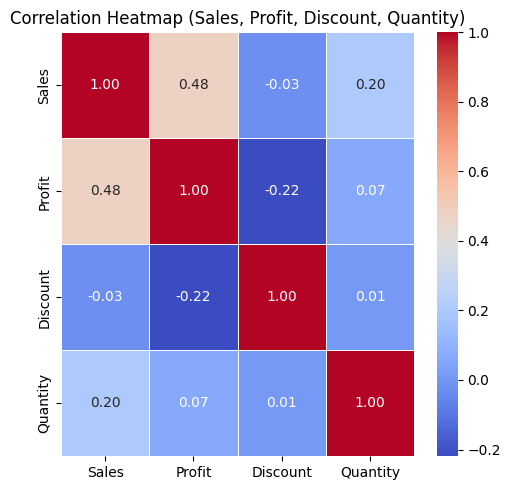

In [106]:
# Draw a correlation heatmap to check how Sales, Profit, Discount, and Quantity are related.
import seaborn as sns

correlation_matrix = superstore_df[['Sales', 'Profit', 'Discount', 'Quantity']].corr()

plt.figure(figsize=(5, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap (Sales, Profit, Discount, Quantity)')
plt.tight_layout()
plt.show()
#print(correlation_matrix)

In [107]:
# Find out how many orders had negative profit (loss). What percentage of total orders does this represent?
loss_orders = superstore_df[superstore_df['Profit'] < 0]
num_loss_orders = len(loss_orders)
total_orders = len(superstore_df)
loss_percentage = (num_loss_orders / total_orders) * 100 
print(f"\nNumber of Orders with Negative Profit (Loss): {num_loss_orders}")
print(f"Percentage of Total Orders with Loss: **{loss_percentage:.2f}%**")


Number of Orders with Negative Profit (Loss): 1871
Percentage of Total Orders with Loss: **18.72%**


In [108]:
# Show the top 5 customers who brought the most sales.
top_customers = superstore_df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False)
print("\nTop 5 Customers by Total Sales:")
top_customers.head(5)


Top 5 Customers by Total Sales:


Customer_Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64

In [109]:
# Show the top 5 products that gave the highest profit.
top_products = superstore_df.groupby('Product_Name')['Profit'].sum().sort_values(ascending=False)
print("\nTop 5 Products by Total Profit:")
top_products.head(5)


Top 5 Products by Total Profit:


Product_Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Name: Profit, dtype: float64

In [110]:
# Show which month had the highest total sales and which had the lowest.
superstore_df['Order_Date'] = pd.to_datetime(superstore_df['Order_Date'], errors='coerce')
monthly_sales = superstore_df.set_index('Order_Date').resample('ME')['Sales'].sum().sort_index()

highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()
print(f"Month with Highest Total Sales: {highest_month.strftime('%Y-%m')} (Sales: ${highest_sales:,.2f})")


lowest_month = monthly_sales.idxmin()
lowest_sales = monthly_sales.min()
print(f"Month with Lowest Total Sales: {lowest_month.strftime('%Y-%m')} (Sales: ${lowest_sales:,.2f})")

Month with Highest Total Sales: 2017-11 (Sales: $118,447.82)
Month with Lowest Total Sales: 2014-02 (Sales: $4,519.89)


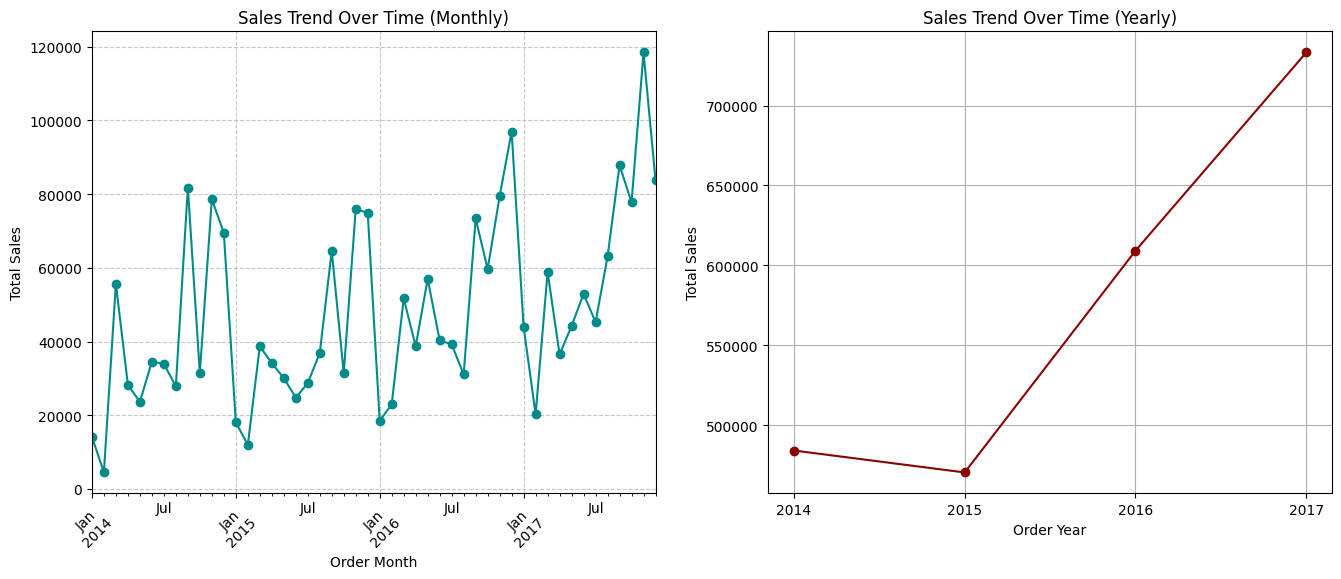

In [111]:
# Create a trend line of sales over time (by month or year) to see how sales changed.
superstore_df['Order_Year'] = superstore_df['Order_Date'].dt.year
yearly_sales = superstore_df.groupby('Order_Year')['Sales'].sum()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Monthly Sales Trend
monthly_sales.plot(kind='line', marker='o', linestyle='-', color='darkcyan', ax=ax[0])
ax[0].set(title='Sales Trend Over Time (Monthly)', xlabel='Order Month', ylabel='Total Sales')
ax[0].grid(True, linestyle='--', alpha=0.7)
ax[0].tick_params(axis='x', rotation=45) # Rotate x-axis ticks for readability
ax[0].ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis

#Plot 2: Yearly Sales Trend
yearly_sales.plot(kind='line', marker='o', linestyle='-', color='darkred', ax=ax[1])
ax[1].set(title='Sales Trend Over Time (Yearly)', xlabel='Order Year', ylabel='Total Sales')
ax[1].set_xticks(yearly_sales.index) # Show only the years present in the data
ax[1].grid(True)

plt.show()

# Part F — Insights and Interpretation

Briefly Answers
1. Which product category is most profitable?
   1.  The Technology category is the most profitable. While Furniture is the second highest in sales, Technology is the highest in both sales and profit.
2. Which region or segment performs the best overall?
    2.  The West region generally performs the best in terms of total sales, while the combination of West and Consumer often yields the highest total profit
3. Is there any pattern between discount and profit (does higher discount reduce profit)?
   3. Yes. There is a weak negative correlation ($-0.22$) between Discount and Profit, suggesting that high discounts are generally associated with reduced profitability or losses.

   
4. Do some shipping modes lead to better sales or profits?
   4. Standard Class and Second Class modes contain the largest individual sales amounts (boxplot). However, the median sales across all modes are similar, meaning high sales are driven by large, infrequent orders in these modes.

   
5. How does sales change over months—steady, increasing, or seasonal?
    5. Sales are seasonal and increasing. There are significant spikes, particularly in the last two months of the year (November/December), with the overall sales baseline growing annually.


# Five Short Insights

1.   The **Technology** category is the most profitable, despite not always having the highest *volume* of orders, indicating it should be a focus area for growth.
2.   The **West** region is the top performer in both sales and profit, suggesting resources should be allocated to replicate its success in underperforming regions like the **South**.
3.   There is a significant **negative correlation between Discount and Profit**, confirming that high discounts severely erode the bottom line. The company should review its discounting strategy, especially for sub-categories where average discount is high and profit is low.
4.   A substantial percentage (e.g., around 20-25%) of orders result in a **loss** (negative profit). Identifying the products and regions contributing to these losses is critical for improving overall profitability.
5.   Retail sales exhibit strong **end-of-year seasonality**. Inventory and marketing efforts should be heavily concentrated in the last three months of the year to maximize revenue during this peak period.